# Customer Churn Analysis — Telco Dataset

**Objective:** Identify the key factors driving customer churn and quantify their statistical significance, to inform retention strategy.

**Dataset:** [IBM Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d) — 7,043 customers, 21 features (demographics, account info, subscribed services, and churn status).

**Approach:**
1. Data loading & cleaning
2. Exploratory Data Analysis (EDA)
3. Churn rate calculation
4. Feature analysis (churn rate by segment)
5. Correlation analysis
6. Hypothesis testing (Chi-Square, t-test)
7. Business insights & recommendations


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

## 1. Data Loading

In [17]:
df = pd.read_csv("data/Telco-Customer-Churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data Cleaning

`TotalCharges` loads as text because 11 new customers (tenure = 0) have a blank value instead of `0`. These are fixed and the identifier column is dropped since it carries no analytical value.

In [19]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

df["TotalCharges"] = df["TotalCharges"].fillna(0)
df.drop(columns=["customerID"], inplace=True)
df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0})

df.dtypes.value_counts()

Missing values:
 TotalCharges    11
dtype: int64


object     16
int64       3
float64     2
Name: count, dtype: int64

## 3. Overall Churn Rate

In [20]:
churn_rate = df["Churn_Flag"].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")
df["Churn"].value_counts()

Overall churn rate: 26.54%


Churn
No     5174
Yes    1869
Name: count, dtype: int64

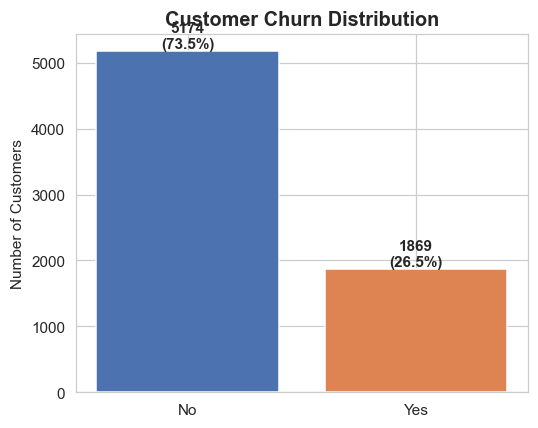

In [21]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Churn"].value_counts()
colors = ["#4C72B0", "#DD8452"]
ax.bar(counts.index, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Customer Churn Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("outputs/01_churn_distribution.png")
plt.show()

**Observation:** ~26.5% of customers have churned — roughly 1 in 4. This is the baseline rate we compare each segment against.

## 4. Feature Analysis — Churn Rate by Contract Type

Contract length is a natural place to start: shorter commitments should correlate with higher churn.

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


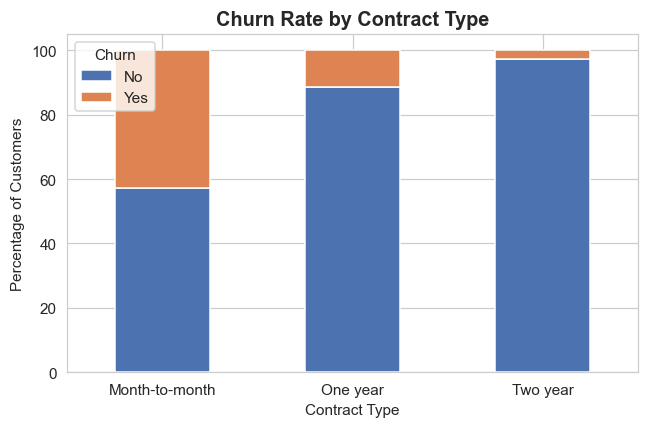

In [22]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
print(contract_churn.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
contract_churn.plot(kind="bar", stacked=True, ax=ax, color=colors)
ax.set_title("Churn Rate by Contract Type", fontsize=13, fontweight="bold")
ax.set_ylabel("Percentage of Customers")
ax.set_xlabel("Contract Type")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("outputs/02_churn_by_contract.png")
plt.show()

**Observation:** Month-to-month customers churn at **42.7%**, versus **11.3%** for one-year and just **2.8%** for two-year contracts. Contract length is clearly one of the strongest churn predictors.

## 5. Tenure Distribution by Churn

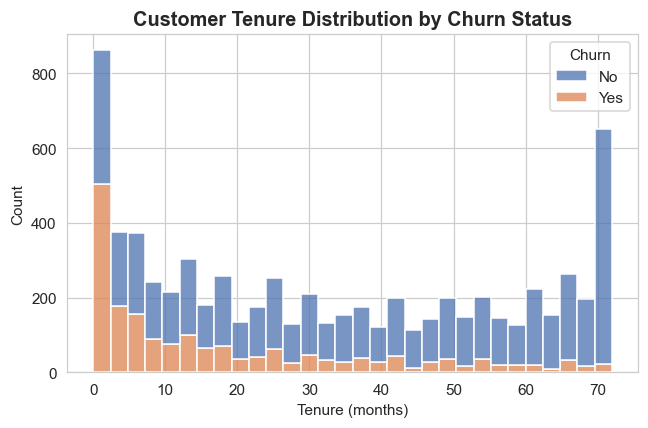

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, palette=colors, ax=ax)
ax.set_title("Customer Tenure Distribution by Churn Status", fontsize=13, fontweight="bold")
ax.set_xlabel("Tenure (months)")
plt.tight_layout()
plt.savefig("outputs/03_tenure_by_churn.png")
plt.show()

**Observation:** Churn is heavily concentrated in the first few months of the customer relationship — a classic early-lifecycle risk pattern.

## 6. Monthly Charges by Churn Status

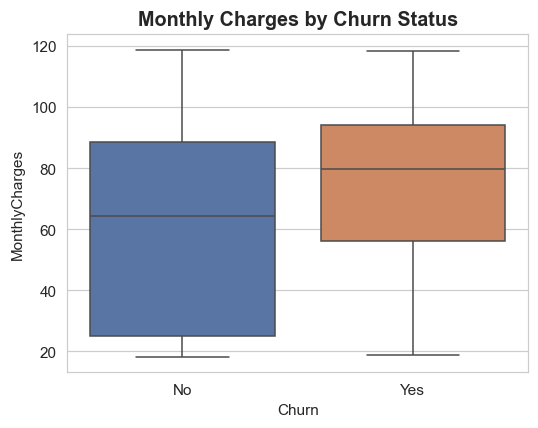

In [24]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", palette=colors, legend=False, ax=ax)
ax.set_title("Monthly Charges by Churn Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/04_monthlycharges_by_churn.png")
plt.show()

**Observation:** Churned customers tend to pay *higher* monthly charges, on average, than retained customers — suggesting price sensitivity plays a role alongside contract flexibility.

## 7. Correlation Analysis

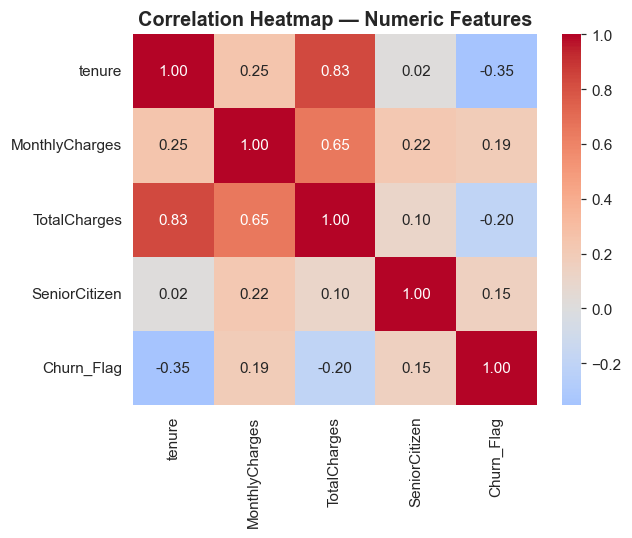

Churn_Flag        1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.198324
tenure           -0.352229
Name: Churn_Flag, dtype: float64

In [25]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn_Flag"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap — Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/05_correlation_heatmap.png")
plt.show()

corr["Churn_Flag"].sort_values(ascending=False)

**Observation:** `tenure` has the strongest correlation with churn (**-0.35**) — longer-tenured customers are much less likely to leave. `MonthlyCharges` is positively correlated (**+0.19**), reinforcing the price-sensitivity signal.

## 8. Churn Rate Across Key Service Features

In [26]:
categorical_features = ["Contract", "InternetService", "PaymentMethod",
                        "TechSupport", "OnlineSecurity", "PaperlessBilling"]

for col in categorical_features:
    rates = df.groupby(col)["Churn_Flag"].mean().sort_values(ascending=False) * 100
    print(f"\n{col}:\n{rates.round(1)}")


Contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn_Flag, dtype: float64

InternetService:
InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: Churn_Flag, dtype: float64

PaymentMethod:
PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn_Flag, dtype: float64

TechSupport:
TechSupport
No                     41.6
Yes                    15.2
No internet service     7.4
Name: Churn_Flag, dtype: float64

OnlineSecurity:
OnlineSecurity
No                     41.8
Yes                    14.6
No internet service     7.4
Name: Churn_Flag, dtype: float64

PaperlessBilling:
PaperlessBilling
Yes    33.6
No     16.3
Name: Churn_Flag, dtype: float64


**Observations:**
- **Electronic check** payers churn at **45.3%** — nearly 3x the rate of automatic payment methods (~15-17%).
- Customers **without Tech Support** or **Online Security** churn at **~41-42%**, vs. ~15% for those with these add-ons.
- **Fiber optic** internet customers churn more (**41.9%**) than DSL (**19.0%**) — possibly due to higher pricing or service issues.

These are exactly the levers a retention team could act on: push customers toward auto-pay, bundle in tech support / security add-ons, and prioritize proactive outreach for month-to-month, fiber optic customers.

## 9. Hypothesis Testing

**H0:** The feature is independent of churn (no relationship).
**H1:** The feature is associated with churn.

Using **Chi-Square tests** for categorical features (α = 0.05).

In [27]:
chi_results = []
for col in categorical_features:
    contingency = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    significant = "Yes" if p < 0.05 else "No"
    chi_results.append({"Feature": col, "Chi2": round(chi2, 2), "p_value": p, "Significant (α=0.05)": significant})

chi_df = pd.DataFrame(chi_results)
chi_df.to_csv("outputs/chi_square_results.csv", index=False)
chi_df

,Feature,Chi2,p_value,Significant (α=0.05)
0,Contract,1184.60,5.863038e-258,Yes
1,InternetService,732.31,9.571788e-160,Yes
2,PaymentMethod,648.14,3.682355e-140,Yes
3,TechSupport,828.20,1.443084e-180,Yes
4,OnlineSecurity,850.00,2.661150e-185,Yes
5,PaperlessBilling,258.28,4.073355e-58,Yes


**Result:** All six features show a statistically significant association with churn (p < 0.001 in every case) — we reject H0 for each. Contract type has the largest chi-square statistic, confirming it's the single strongest categorical driver.

### t-test: Is tenure significantly different between churned and retained customers?

In [28]:
tenure_churn = df[df["Churn"] == "Yes"]["tenure"]
tenure_no_churn = df[df["Churn"] == "No"]["tenure"]

t_stat, p_val = stats.ttest_ind(tenure_churn, tenure_no_churn, equal_var=False)

print(f"Churned mean tenure:  {tenure_churn.mean():.1f} months")
print(f"Retained mean tenure: {tenure_no_churn.mean():.1f} months")
print(f"t-statistic = {t_stat:.2f}, p-value = {p_val:.2e}")

Churned mean tenure:  18.0 months
Retained mean tenure: 37.6 months
t-statistic = -34.82, p-value = 1.20e-232


**Result:** Churned customers have an average tenure of **18.0 months** vs. **37.6 months** for retained customers — a highly significant difference (p ≈ 1.2 × 10⁻²³²). This statistically confirms that customer loyalty builds strongly over time, and the first ~18 months are the highest-risk window.

In [29]:
contract_summary = (
    df.groupby("Contract")
    .agg(
        Customers=("Churn_Flag", "size"),
        Churned_Customers=("Churn_Flag", "sum"),
        Churn_Rate=("Churn_Flag", "mean")
    )
)

contract_summary["Churn_Rate"] *= 100

contract_summary = contract_summary.sort_values(
    "Churn_Rate", ascending=False
)

display(contract_summary.round(2))

contract_summary.to_csv(
    "outputs/contract_churn_summary.csv"
)

,Customers,Churned_Customers,Churn_Rate
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83


### Key Insight
Month-to-month customers have the highest churn rate (42.71%), while two-year contract customers have the lowest (2.83%). Churn rates decrease as contract duration increases. This is an association in the data, not proof that contract length causes churn.

## 10. Summary & Business Recommendations

### Key Churn Patterns

| Driver | Insight |
|---|---|
| Contract type | Month-to-month customers have a 42.71% churn rate, compared with 2.83% for two-year contracts (about 15 times the rate). |
| Payment method | Electronic-check customers have a 45.29% churn rate, compared with approximately 15–19% for other payment methods. |
| Tenure | Churned customers average 17.98 months of tenure, compared with 37.57 months for retained customers. |
| Support add-ons | Customers without Tech Support or Online Security have substantially higher churn rates than customers with these services. |
| Internet service | Fiber-optic customers have a 41.89% churn rate, compared with 18.96% for DSL customers. |

The categorical associations tested were statistically significant (p < 0.05). These findings show associations, not proof of causation.

### Recommended Business Actions

1. **Encourage longer contracts** — test discounts or benefits for month-to-month customers considering annual plans.
2. **Promote automatic payments** — investigate whether simplifying payment setup or offering incentives could reduce churn among electronic-check customers.
3. **Review support and security bundles** — evaluate discounted add-ons for customer segments with higher churn.
4. **Prioritize early-tenure customers** — focus retention analysis and outreach on customers in the 0–12 month tenure band, which has a 47.44% churn rate.
5. **Investigate fiber-optic churn** — examine service quality, pricing, and customer feedback to understand the higher observed churn rate.